## Student performance indicator

#### life cycle of a machine learning project 

. understanding the problem statement  
. data collection  
. data checks to performance  
. exploratory data analysis  
. data pre-processing  
. model training  
. choose best model

### 1) Problem statement
- the project want to understand how various factors like gender, ethnicity, parental level of education, lunch, and test preparation course effects the performance of students 


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#### Import the CSV Data as Pandas DataFrame

In [2]:
df = pd.read_csv(r"data/stud.csv")
df

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


show first 5 records

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


shape of dataset

In [4]:
df.shape

(1000, 8)

### 2.2 Dataset information

- gender : sex of students  -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
- lunch : having lunch before test (standard or free/reduced) 
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

In [5]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [8]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [9]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [10]:
df.select_dtypes(include='object').describe()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course
count,1000,1000,1000,1000,1000
unique,2,5,6,2,2
top,female,group C,some college,standard,none
freq,518,319,226,645,642


#### Insight
- From above description of numerical data, all means are very close to each other - between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score  0 for math, for writing minimum is much higher = 10 and for reading is much higher = 17

In [11]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [12]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:      ['female' 'male']
Categories in 'race_ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:      ['standard' 'free/reduced']
Categories in 'test preparation course' variable:      ['none' 'completed']


In [13]:
numeric_features = df.select_dtypes(exclude='object').columns.to_list()
categorical_features = df.select_dtypes(include='object').columns.to_list()
print(" there are total {} numeric features  =  {} ".format(len(numeric_features) , numeric_features))
print(" there are total {} categorical features  =  {} ".format(len(categorical_features) , categorical_features))



 there are total 3 numeric features  =  ['math_score', 'reading_score', 'writing_score'] 
 there are total 5 categorical features  =  ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course'] 


### 3.8 Adding columns for "Total Score" and "Average"

In [14]:
df['total_score'] = df['math_score'] + df['reading_score']+ df['writing_score']
df['score_average'] = df['total_score']/3 
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,score_average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [15]:
reading_fullmarks = df[df['reading_score']==100]['lunch'].count()
writing_fullmarks = df[df['writing_score']==100]['lunch'].count()
maths_fullmarks = df[df['math_score']==100]['lunch'].count()
reading_fullmarks , writing_fullmarks , maths_fullmarks

(np.int64(17), np.int64(14), np.int64(7))

### 4. Exploring Data ( Visualization )
#### 4.1 Visualize average score distribution to make some conclusion. 
- Histogram
- Kernel Distribution Function (KDE)

#### 4.1.1 Histogram & KDE

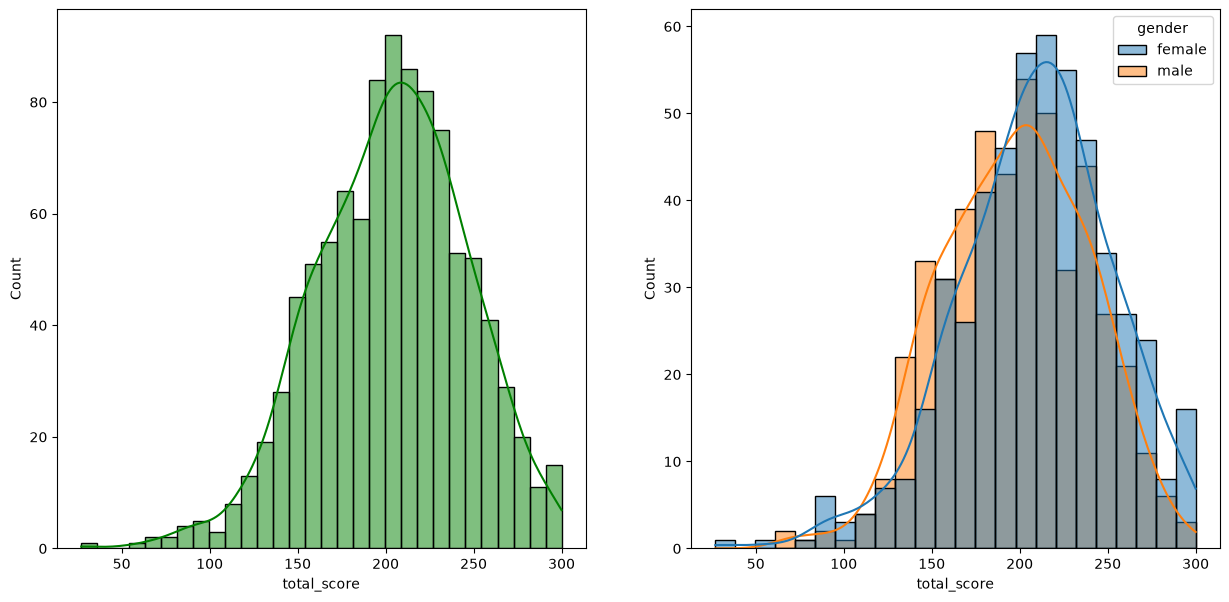

In [26]:
fig , axs = plt.subplots(1,2,figsize=(15,7))
##this creates a figure containing 2 plots 
sns.histplot(data=df,x='total_score',bins=30,kde=True,color='g',ax=axs[0])
## data contains the data , x defines the x_axis , bins means the total intervals are 30  
## ax=axs[0] = selects the first plot out of the 2
## kde = kernel density estimate - estimated overall distribution shape
sns.histplot(data=df,x='total_score',kde=True,hue='gender',ax=axs[1])
## hue - separate the distribution accoroding 
plt.show()  

Graph 1 asks:

How are students' average scores distributed overall?

Graph 2 asks:

How are average scores distributed for male and female students separately?

 Interpretation -  
1) Most students have average scores around the middle-to-upper range, while relatively few students are at the extreme ends.  
2) Female students appear to have a somewhat higher average score distribution than male students in this dataset.

In [23]:
print("count of males students- " , df[df['gender']=='male']['gender'].count())
print("count of feamale students - " , df[df['gender']=='female']['gender'].count())


count of males students-  482
count of feamale students -  518


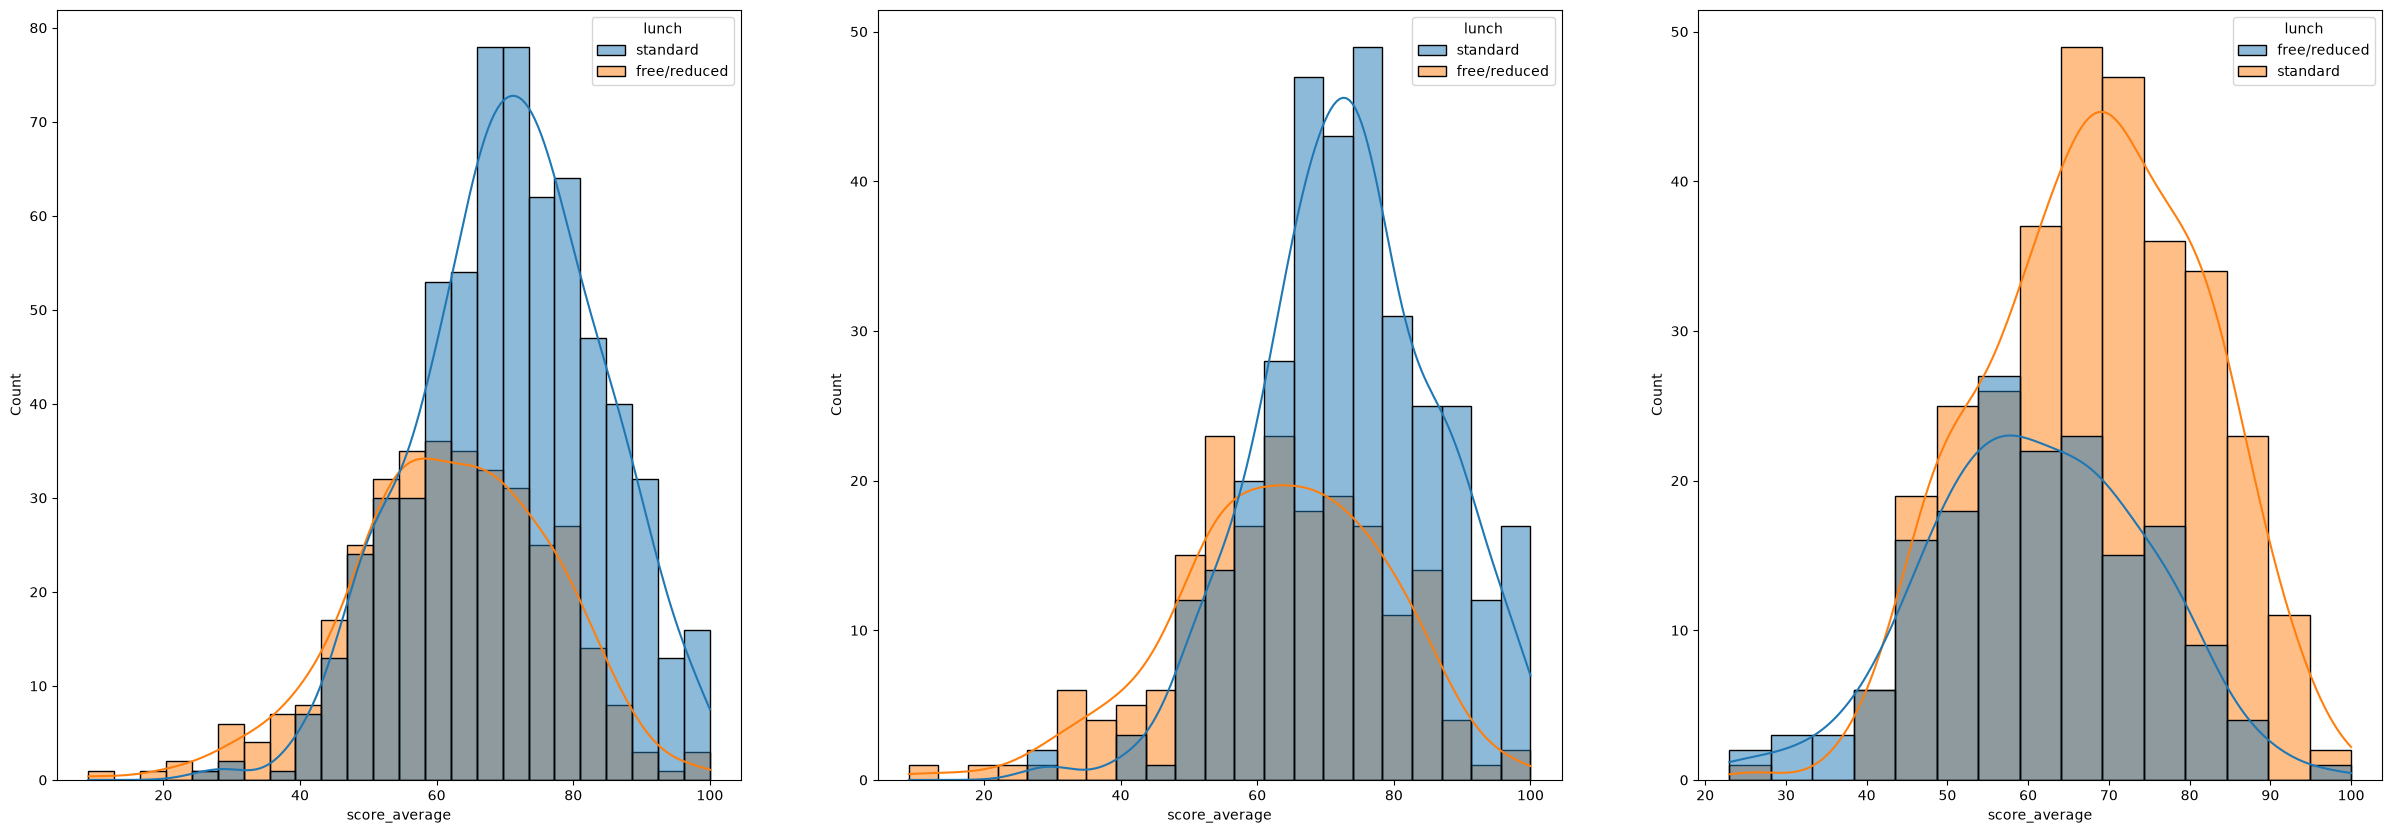

In [31]:
plt.subplots(1,3,figsize=(30,10))
plt.subplot(131)
sns.histplot(data=df,x='score_average',kde=True,hue='lunch')
plt.subplot(132)
sns.histplot(data=df[df.gender=='female'],x='score_average',kde=True,hue='lunch')
plt.subplot(133)
sns.histplot(data=df[df.gender=='male'],x='score_average',kde=True,hue='lunch')
plt.show()

Questions-  
1) How are scores distributed for students who receive standard lunch versus free/reduced lunch?  
2) Among female students, how do scores differ between lunch categories?  
3) same for boys  
Interpretations -  
1) @1st graph -  Students with standard lunch tend to have higher average scores than students with free/reduced lunch in this dataset.  
2) @2nd graph - Among female students, those with standard lunch tend to have higher average scores than those with free/reduced lunch.  
3) @3rd graph - similar readings 

<Axes: xlabel='score_average', ylabel='Count'>

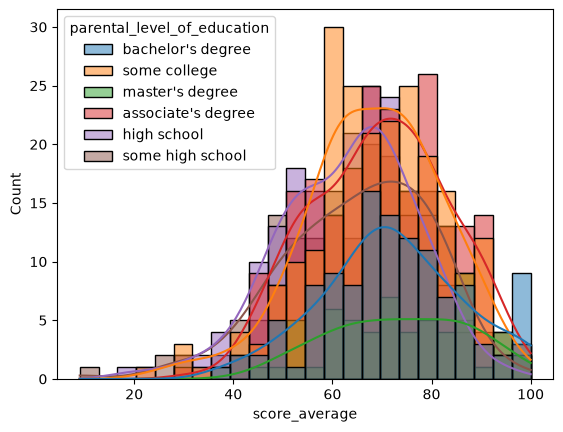

In [32]:
# fig , axs = plt.subplots(1,3,figsize=(25,6))
sns.histplot(data=df,x='score_average',kde=True,hue='parental_level_of_education')

Questions -  
1) Do students' average scores appear to differ depending on their parents' level of education?  
Interpretation -  
1) There appears to be an association between parental education level and student scores, with some higher parental-education groups showing distributions shifted toward higher scores. However, the distributions overlap substantially.

<Axes: xlabel='score_average', ylabel='Count'>

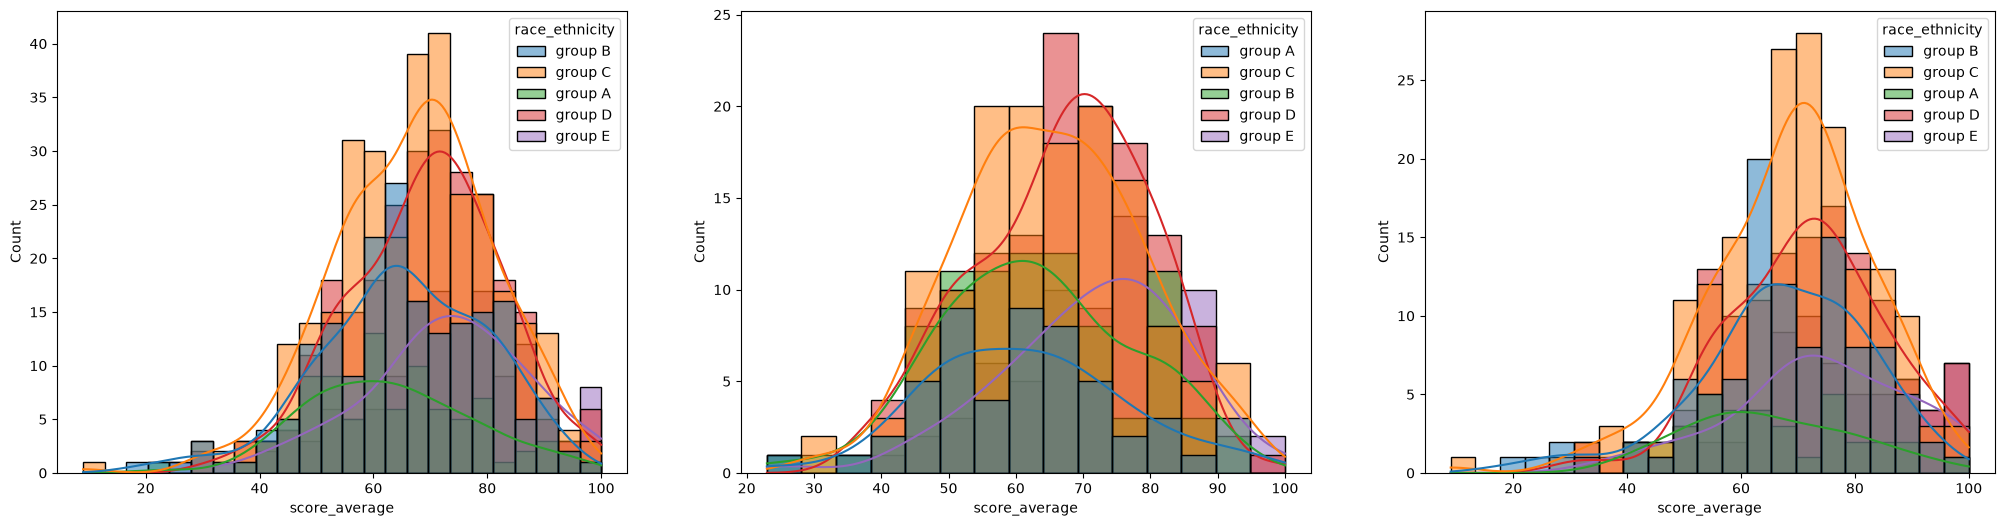

In [35]:
fig , axs = plt.subplots(1,3,figsize=(25,6))
sns.histplot(data=df,x='score_average',kde=True , hue='race_ethnicity' , ax=axs[0])
sns.histplot(data=df[df['gender']=='male'],x='score_average',kde=True , hue='race_ethnicity' , ax=axs[1])
sns.histplot(data=df[df['gender']=='female'],x='score_average',kde=True , hue='race_ethnicity' , ax=axs[2])

Questions-  
1)Do average scores appear to differ between race_ethnicity groups?  
2)Is the relationship between race/ethnicity and scores similar for males and females?  
3)How much do the score distributions overlap between groups?  
This tells you whether the groups are strongly separated or whether students from different groups have similar scores.

Interpretation-  
1)Average scores appear to vary across race/ethnicity groups in this dataset.  
2)The groups have different score distributions, but there is substantial overlap between them.  
So you shouldn't conclude: "Group C students are high scorers and Group B students are low scorers."  
3)Among both male and female students, there appears to be variation in average scores across race/ethnicity groups. but again there were significant overlaps.  
4)The association between race/ethnicity and average score is not simply a pattern seen in one gender; differences between groups appear in both male and female distributions.

<Axes: xlabel='score_average', ylabel='Count'>

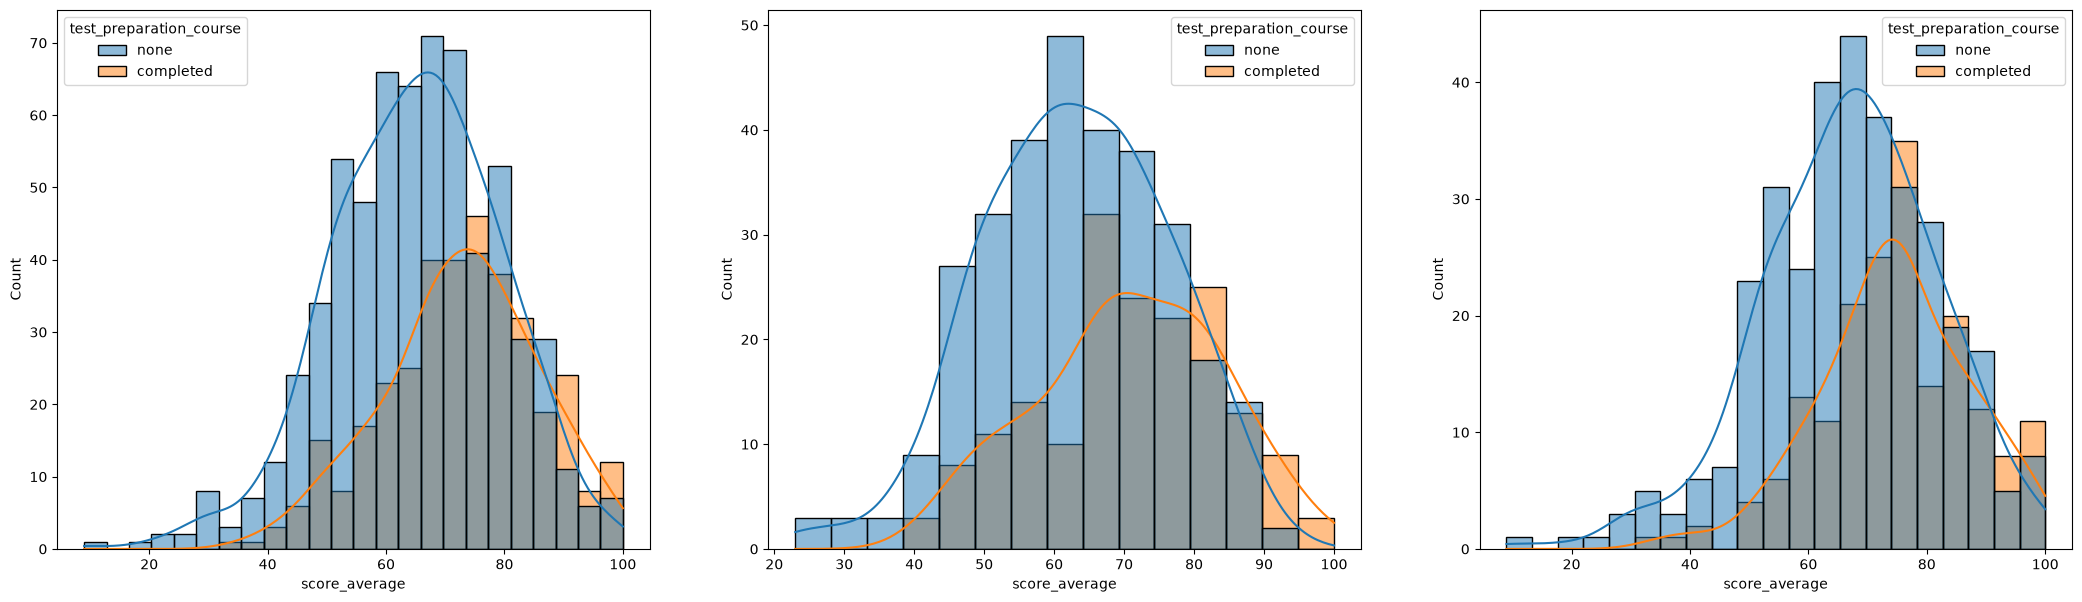

In [37]:
fig , axs = plt.subplots(1,3 , figsize=(26,7))
sns.histplot(data=df,x='score_average',kde=True,hue='test_preparation_course',ax=axs[0])
sns.histplot(data=df[df['gender']=='male'],x='score_average',kde=True,hue='test_preparation_course',ax=axs[1])
sns.histplot(data=df[df['gender']=='female'],x='score_average',kde=True,hue='test_preparation_course',ax=axs[2])


Questions-  
1)Do students who completed a test preparation course have different score distributions from students who did not?  
2)Does the difference remains the same among male/female students ?

Interpretation-  
1)Students who completed the test preparation course tend to have higher average scores than students who did not complete it.  
2)Both Male & Female students who completed the test preparation course appear to have higher average scores than students who did not   

#### 4.2 Maximumum score of students in all three subjects

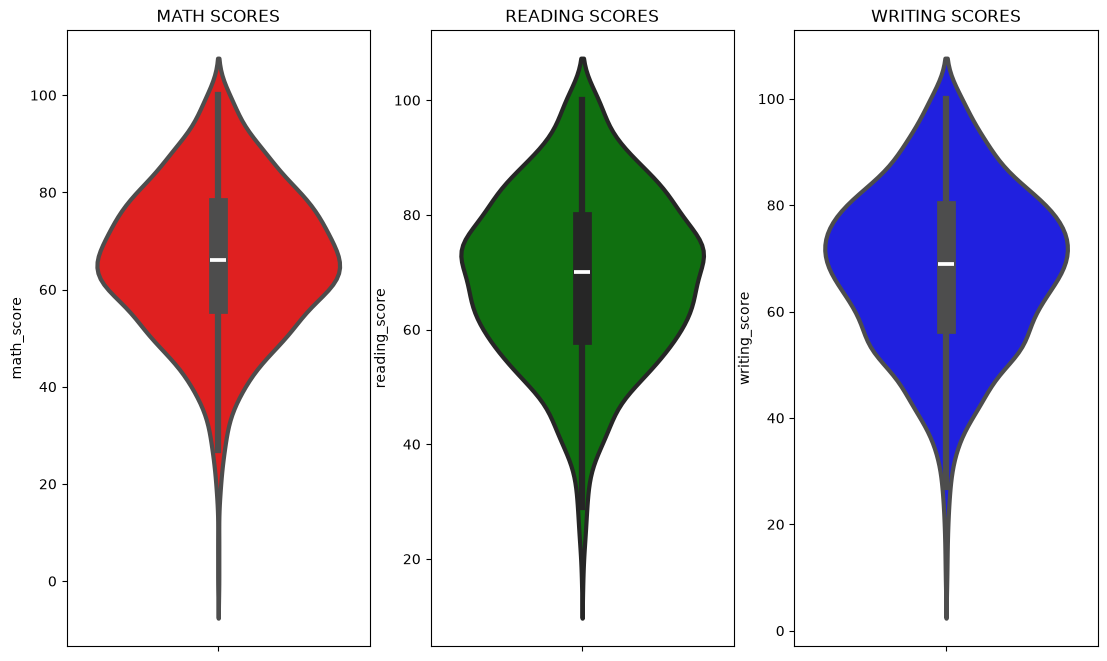

In [39]:

plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()

Interpretation-  
1)Reading scores appear to have the highest median, writing scores are slightly lower, and math scores have the lowest median among the three.  

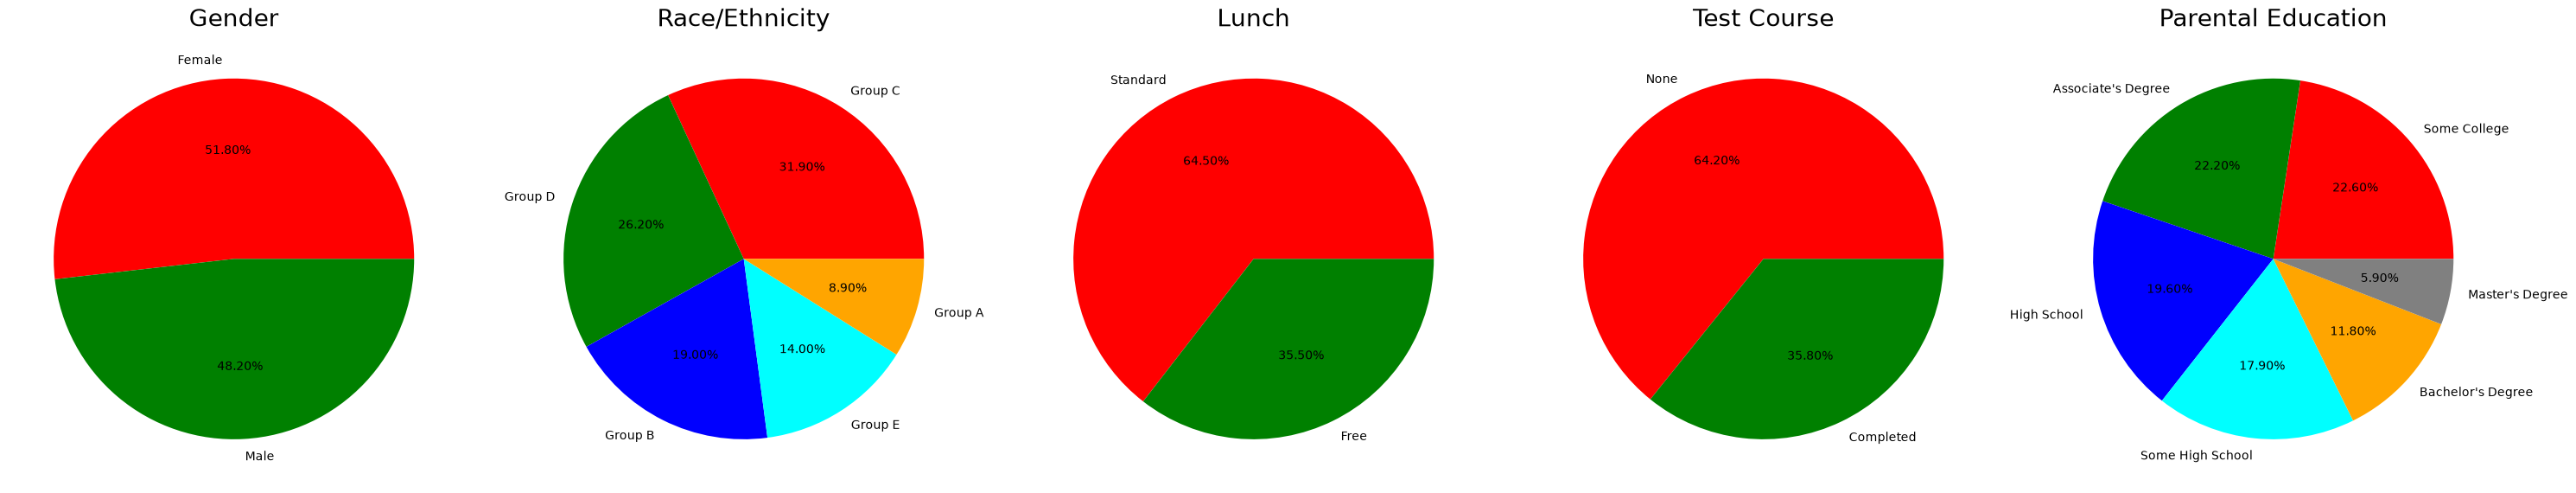

In [47]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '%.2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 2)
size = df['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '%.2f%%')
plt.title('Race/Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '%.2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '%.2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '%.2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

#####  Insights
The dataset is relatively balanced in terms of gender, with females representing approximately 51.8% and males 48.2%. The race/ethnicity, lunch, test-preparation, and parental-education categories are not equally distributed. Group C is the largest race/ethnicity group, while Group A is the smallest. Most students have standard lunch and have not completed the test preparation course. Among parental education levels, some college and associate's degree are the most common, while master's degree is the least common.

#### 4.4 Feature Wise Visualization
#### 4.4.1 GENDER COLUMN
- How is distribution of Gender ?
- Is gender has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( How is distribution of Gender ? )

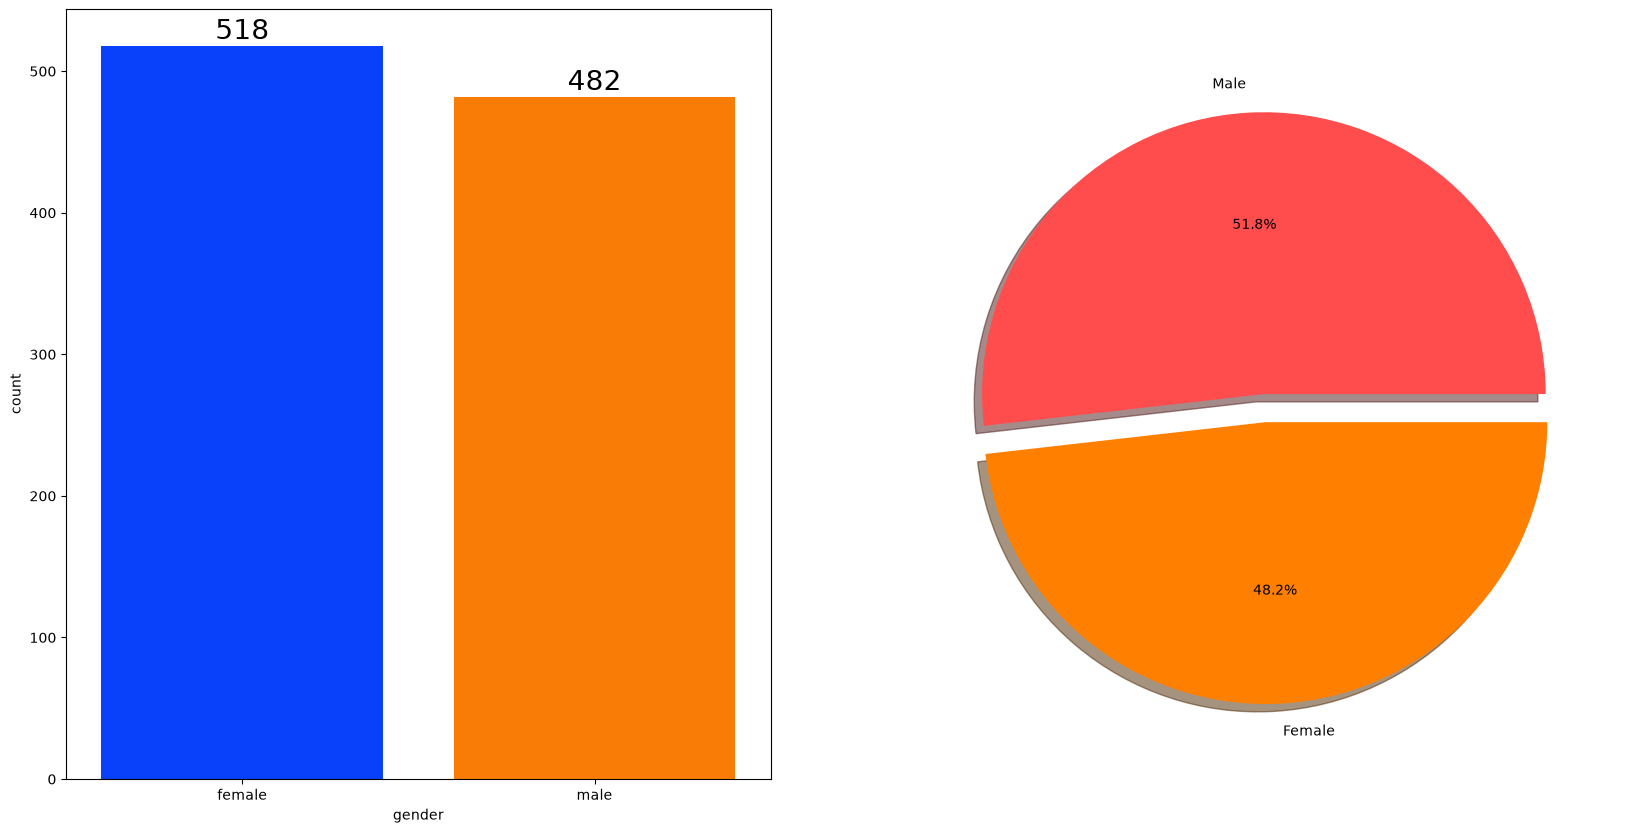

In [44]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

#### BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? ) 

In [51]:
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group

,math_score,reading_score,writing_score,total_score,score_average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


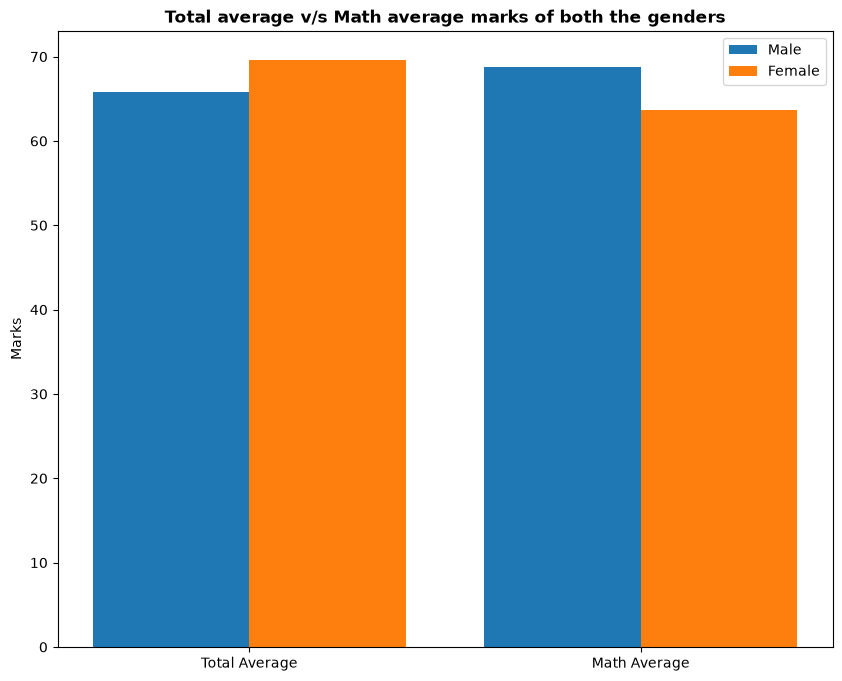

In [ ]:
plt.figure(figsize=(10, 8))

X = ['Total Average','Math Average']


female_scores = [gender_group['score_average'][0], gender_group['math_score'][0]]
male_scores = [gender_group['score_average'][1], gender_group['math_score'][1]]

X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')
  
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

#### Insights 
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.

#### 4.4.2 RACE/EHNICITY COLUMN
- How is Group wise distribution ?
- Is Race/Ehnicity has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

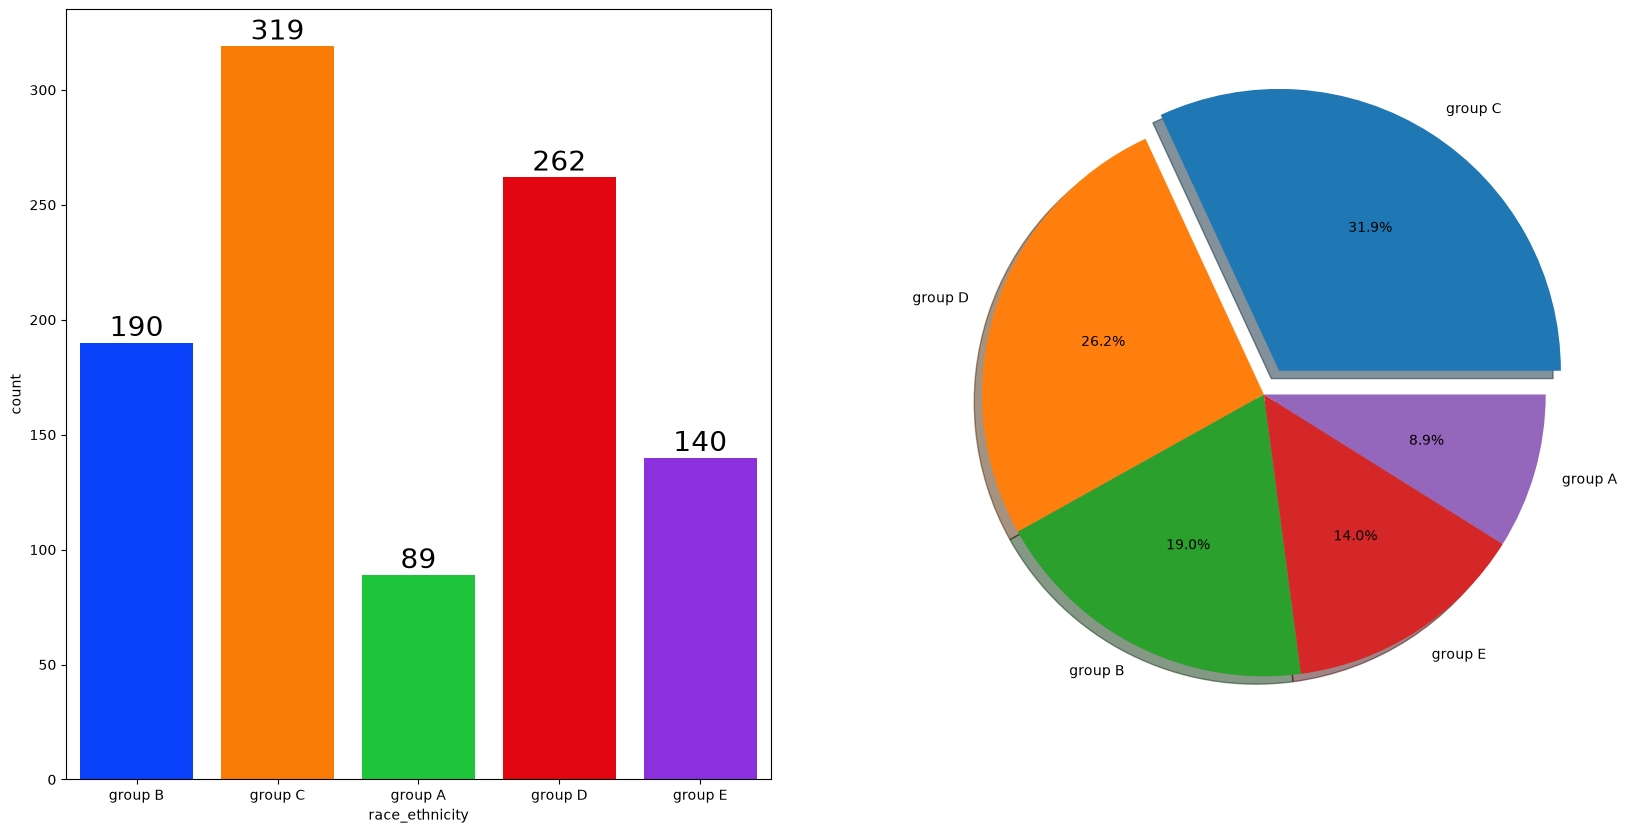

In [54]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race_ethnicity'],data=df,palette = 'bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x = df['race_ethnicity'].value_counts(),labels=df['race_ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show()   

#### Insights 
- Most of the student belonging from group C /group D.
- Lowest number of students belong to groupA.

#### BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

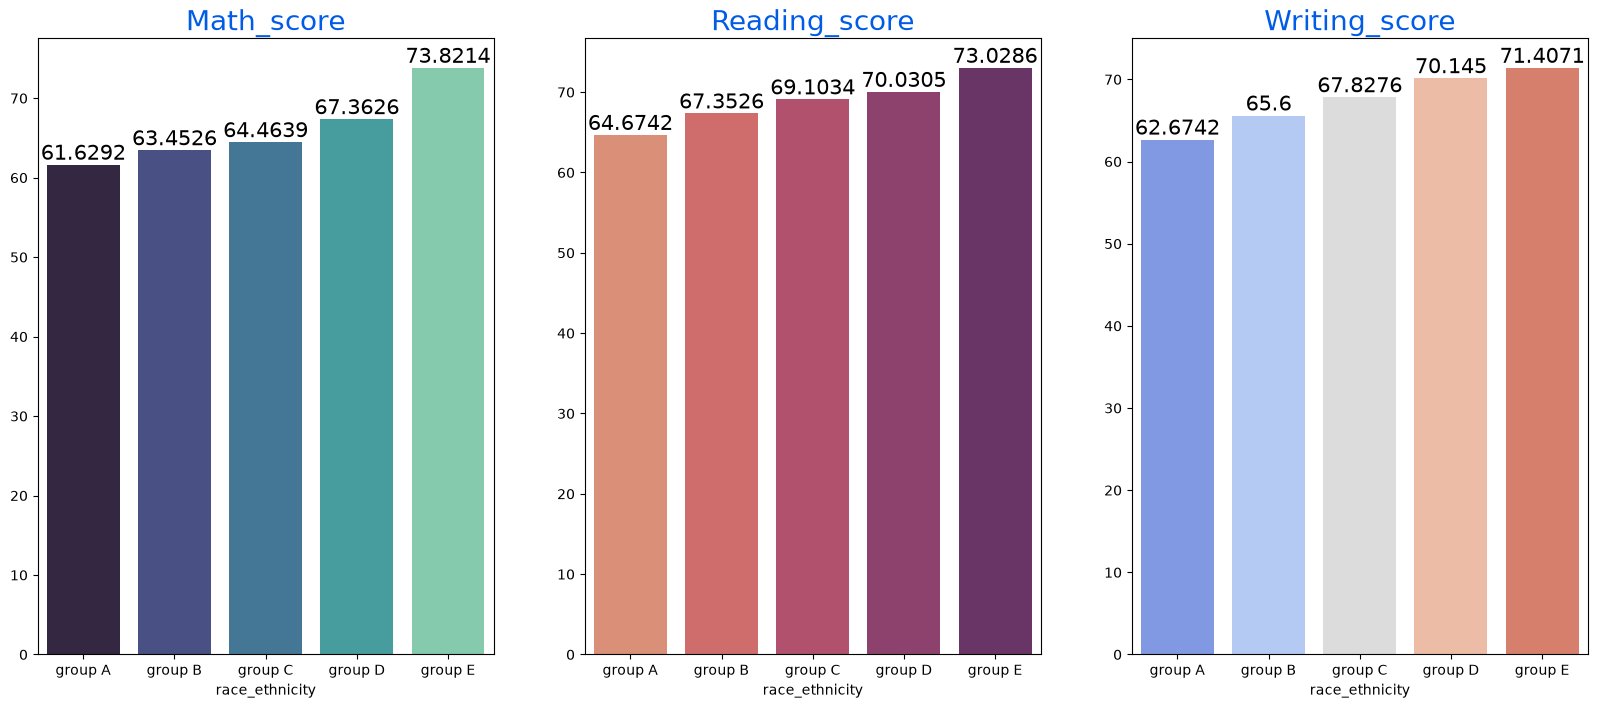

In [55]:
Group_data2=df.groupby('race_ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math_score'].mean().index,y=Group_data2['math_score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math_score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading_score'].mean().index,y=Group_data2['reading_score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading_score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing_score'].mean().index,y=Group_data2['writing_score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing_score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

#### Insights 
- Group E students have scored the highest marks. 
- Group A students have scored the lowest marks. 
- Students from a lower Socioeconomic status have a lower avg in all course subjects

#### 4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN
- What is educational background of student's parent ?
- Is parental education has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

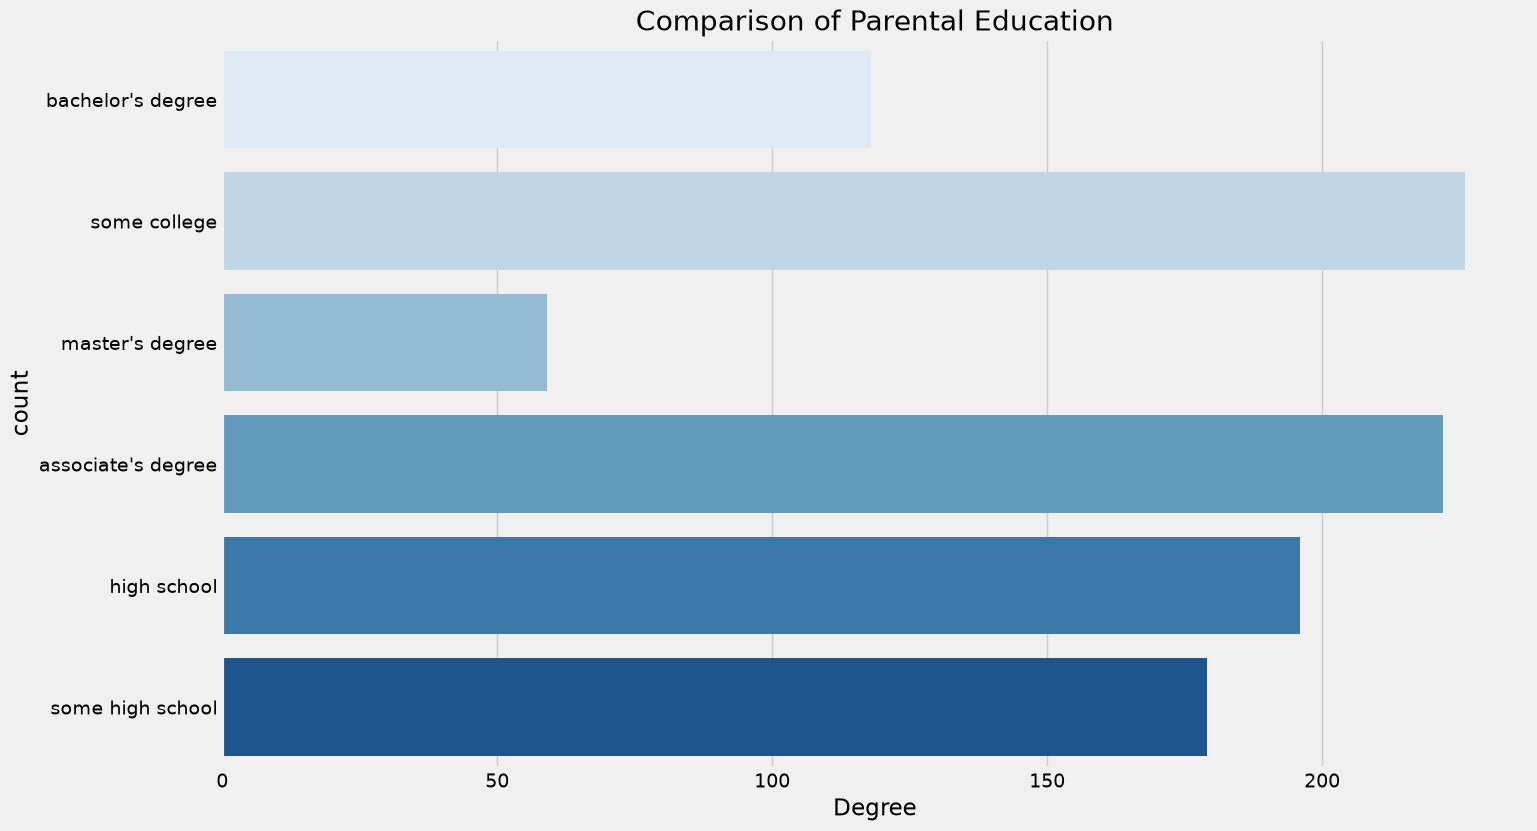

In [59]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental_level_of_education'], palette = 'Blues')
plt.title('Comparison of Parental Education')
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

#### Insights 
- Largest number of parents are from some college.

#### BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

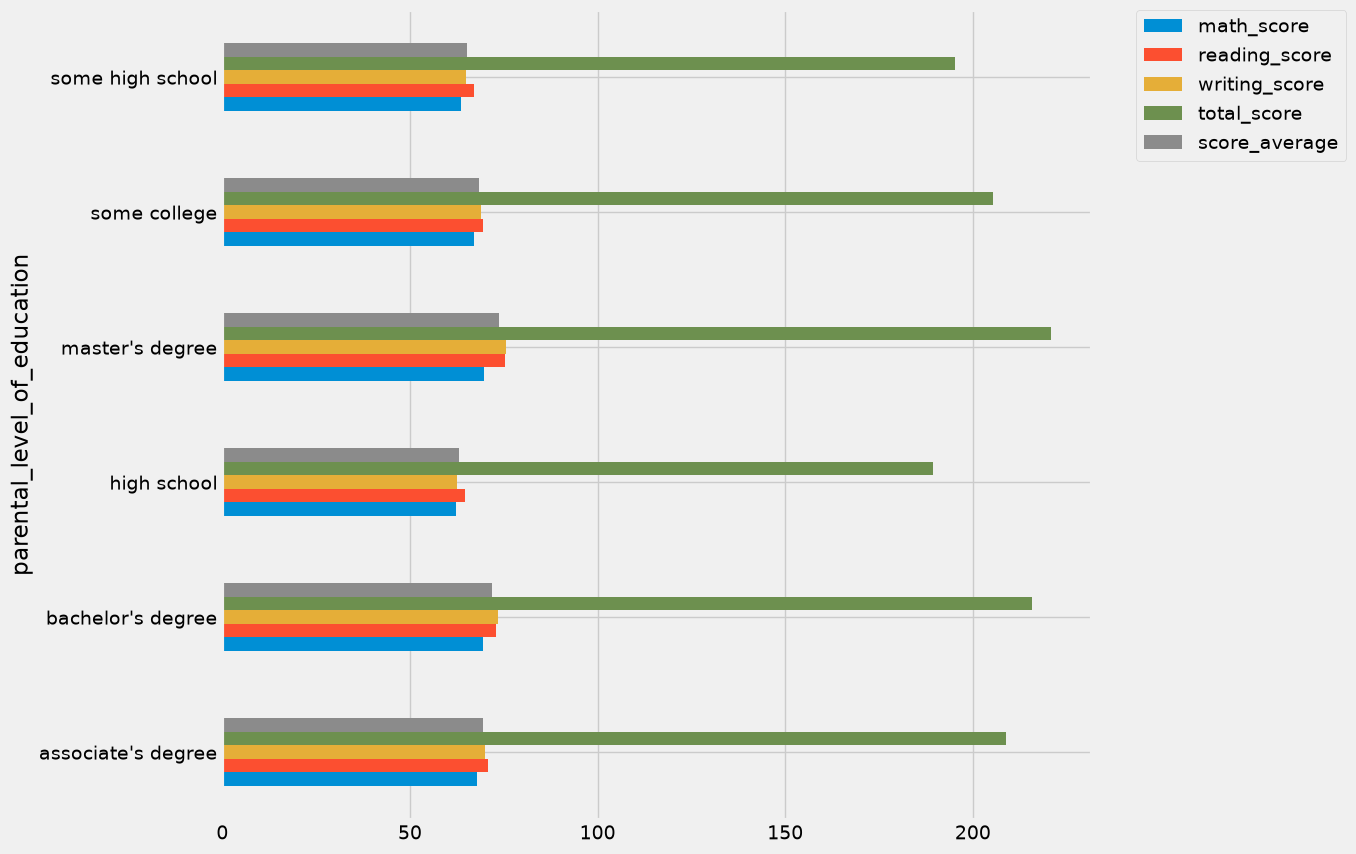

In [ ]:
df.groupby('parental_level_of_education').mean(numeric_only=True).plot(kind='barh',figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

#### Insights 
- The score of student whose parents possess master and bachelor level education are higher than others.

#### 4.4.4 LUNCH COLUMN 
- Which type of lunch is most common amoung students ?
- What is the effect of lunch type on test results?


#### UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

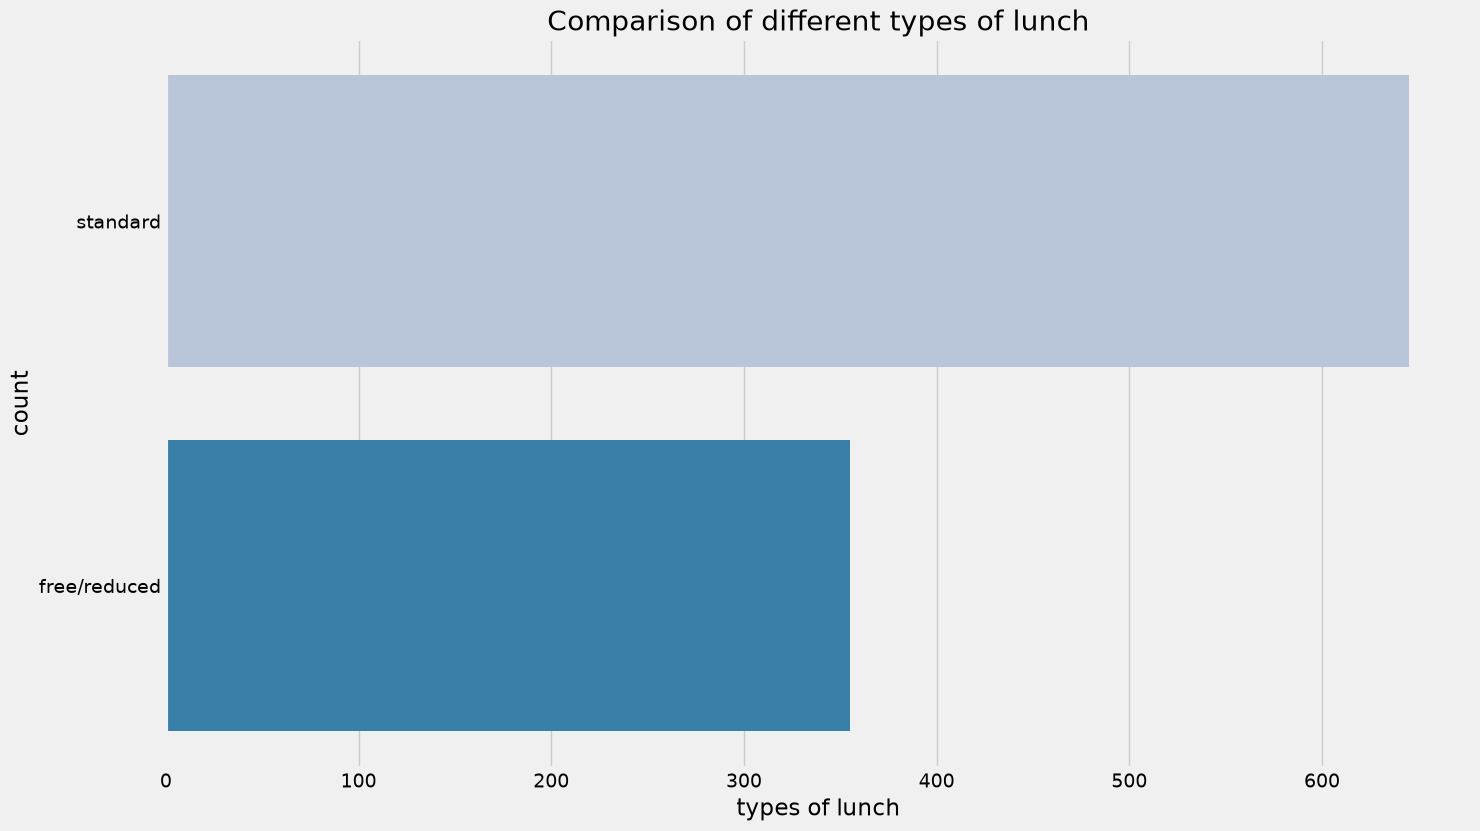

In [64]:
plt.rcParams['figure.figsize'] = (15, 9)
sns.countplot(df['lunch'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

#### Insights 
- Students being served Standard lunch was more than free lunch

#### BIVARIATE ANALYSIS (  Is lunch type intake has any impact on student's performance ? )

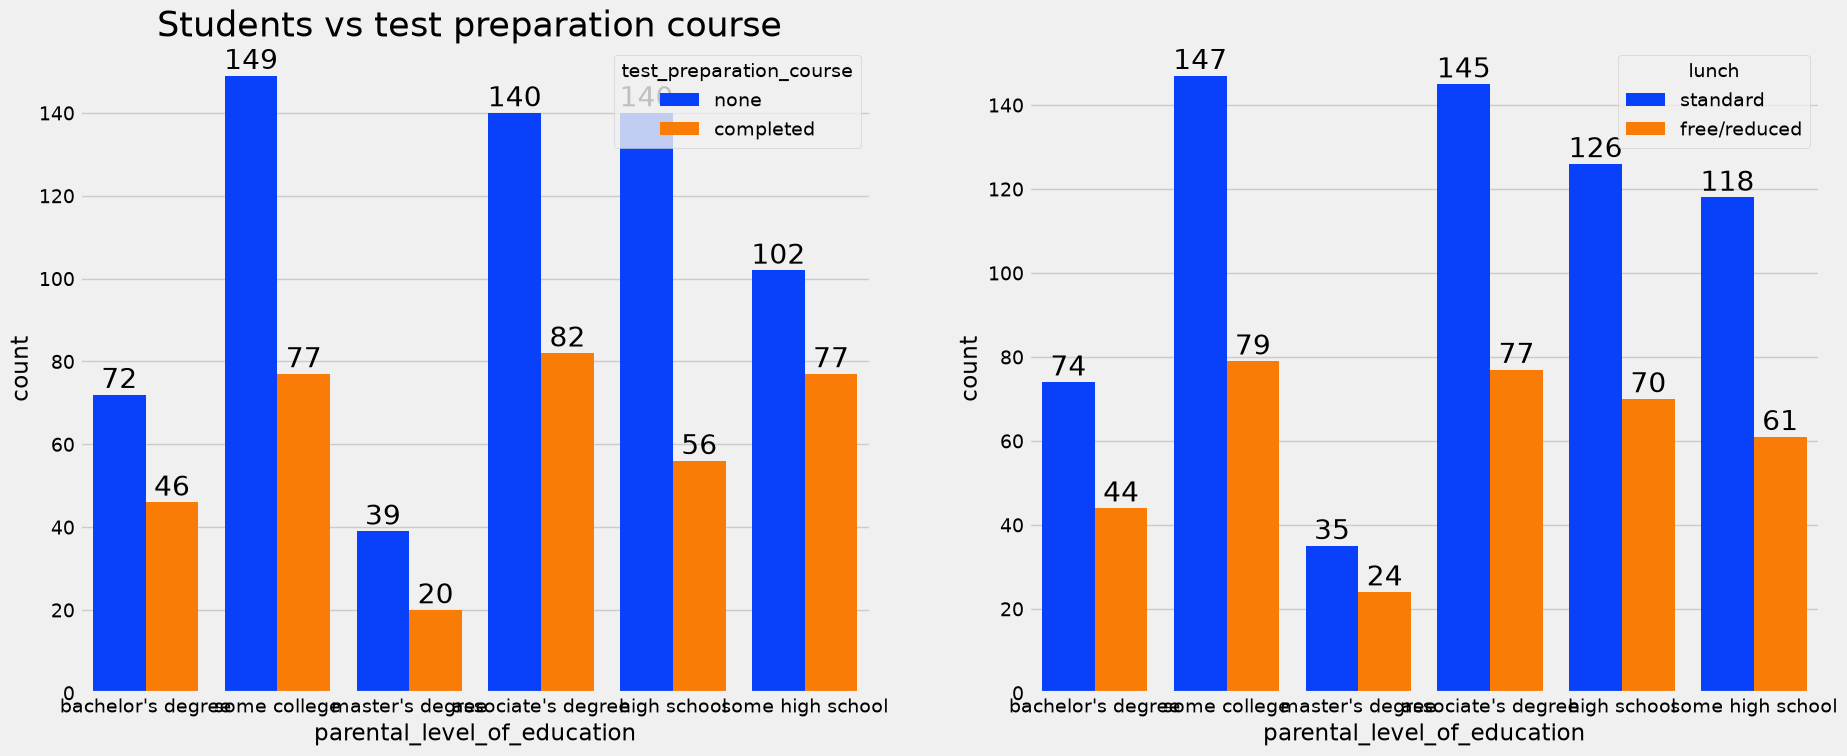

In [66]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=df['parental_level_of_education'],data=df,palette = 'bright',hue='test_preparation_course',saturation=0.95,ax=ax[0])
ax[0].set_title('Students vs test preparation course ',color='black',size=25)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
sns.countplot(x=df['parental_level_of_education'],data=df,palette = 'bright',hue='lunch',saturation=0.95,ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=20)   

Questions -  
1) For each parental education category, how many students completed the test preparation course and how many did not? @graph 1  
2) for each parental education category , how many students are getting standard lunch and how many are not ?

Interpretaion -  
1) from graph 1 - Regardless of parental education level, more students did not complete the test preparation course than completed it.  
2) from graph 2 - Students with standard lunch outnumber students with free/reduced lunch across every parental education category.  


#### 4.4.5 TEST PREPARATION COURSE COLUMN 
- Which type of lunch is most common amoung students ?
- Is Test prepration course has any impact on student's performance ?

#### BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

<Axes: xlabel='lunch', ylabel='writing_score'>

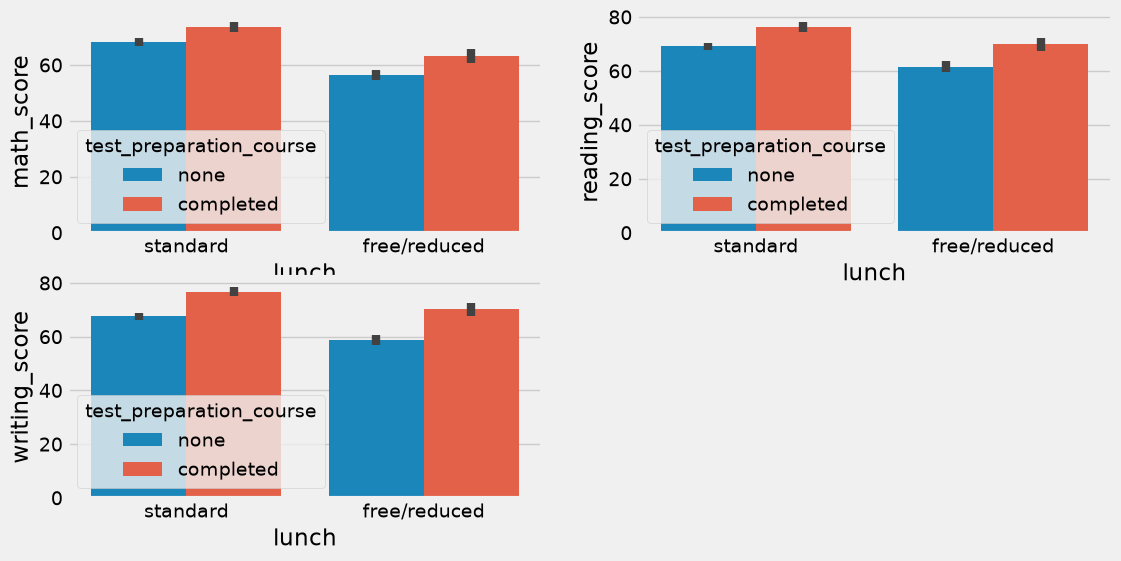

In [68]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.barplot (x=df['lunch'], y=df['math_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,2)
sns.barplot (x=df['lunch'], y=df['reading_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,3)
sns.barplot (x=df['lunch'], y=df['writing_score'], hue=df['test_preparation_course'])

The important thing about barplot is:  

The height of each bar represents the mean (average) of the numerical variable.
So this is NOT showing how many students there are.

Interpretation-  
1)Completion of the test preparation course is associated with higher average math scores in both lunch groups.  


#### 4.4.6 CHECKING OUTLIERS

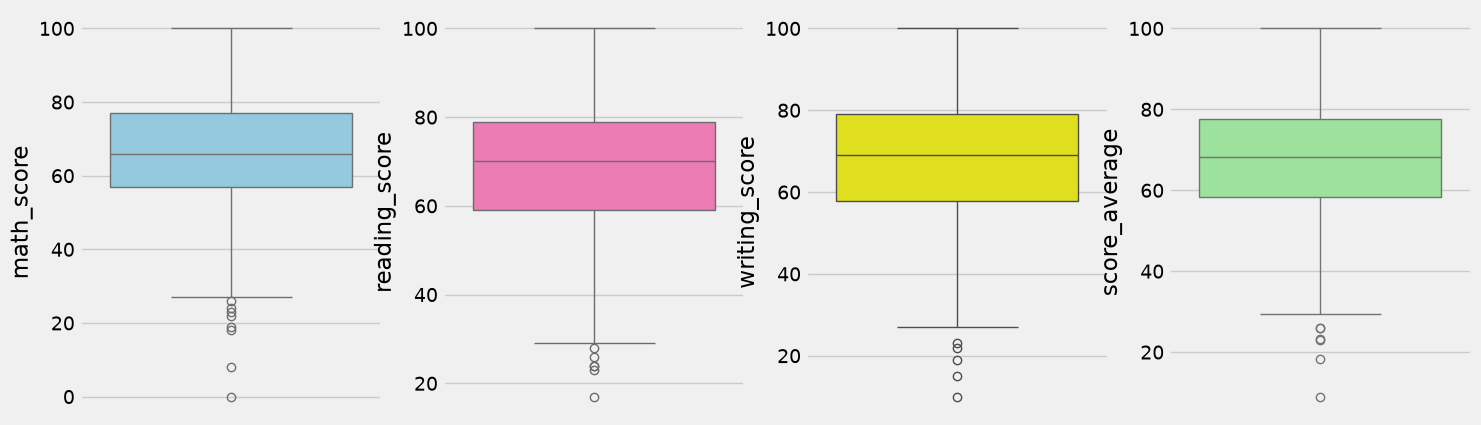

In [69]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['score_average'],color='lightgreen')
plt.show()

#### 4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

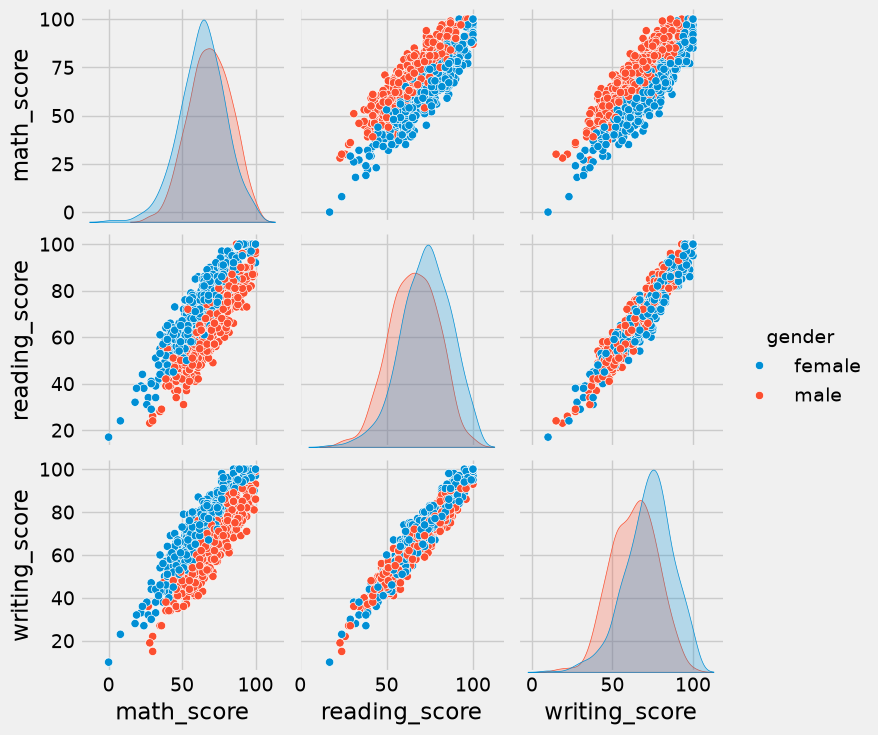

In [71]:
sns.pairplot(df, vars=['math_score', 'reading_score', 'writing_score'], hue = 'gender')
plt.show()

digonals - These aren't scatter plots. , They're KDE/distribution plots.
For example, the top-left plot shows the distribution of math_score.
The pairplot is therefore giving you two types of information:  
Off-diagonal
Relationships between variables  
Diagonal
Distribution of individual variables  
Pairplot → helps you discover relationships visually.

Conclusion:
1)The exploratory data analysis shows several important patterns in student academic performance.  
2)The dataset is relatively balanced by gender, with females making up 51.8% and males 48.2% of the students.  
3)Math, reading, and writing scores are generally concentrated around the middle-to-high score range and show strong positive relationships with one another, indicating that students who perform well in one subject tend to perform well in the others.  
4)Female students tend to have higher reading and writing scores, while the difference in math performance is comparatively smaller.  
5)Students who completed the test preparation course consistently achieved higher average scores across all three subjects.  
6)Similarly, students with standard lunch generally achieved higher average scores than those with free/reduced lunch.  
7)Differences can also be observed across race/ethnicity and parental education groups. However, these analyses identify associations rather than causal relationships.  
8)Further statistical analysis would be required to determine the significance and strength of these relationships and to identify which factors are the strongest predictors of student performance.